# Proyek Analisis Data: Kualitas Udara Stasiun Tiantan
- **Nama:** Muh Restu Yoga Pratama
- **Email:** muhrestuy@gmail.com
- **ID Dicoding:** [Lengkapi ID Dicoding Anda]

Notebook ini menganalisis kualitas udara di Stasiun Tiantan, Beijing, menggunakan dataset PRSA periode 1 Maret 2013 hingga 28 Februari 2017. Fokus utama analisis adalah tren partikulat PM2.5 dan PM10 serta hubungannya dengan musim dan variabel cuaca.

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis disusun dengan prinsip SMART agar spesifik, terukur, relevan, dan dapat dijawab menggunakan data historis yang tersedia.

- **Pertanyaan 1:** Bagaimana tren rata-rata bulanan PM2.5 di Stasiun Tiantan selama periode Maret 2013 hingga Februari 2017, dan pada bulan apa rata-rata PM2.5 mencapai nilai tertinggi serta terendah?
- **Pertanyaan 2:** Pada musim apa tingkat polusi PM2.5 dan PM10 cenderung paling tinggi di Stasiun Tiantan selama periode pengamatan?
- **Pertanyaan 3:** Bagaimana hubungan PM2.5 dengan faktor cuaca seperti suhu, tekanan udara, titik embun, dan kecepatan angin?

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

## Data Wrangling

### Gathering Data

Tahap ini memuat dataset mentah dari folder `data` dan melihat struktur awalnya.

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "PRSA_Data_Tiantan_20130301-20170228.csv"
DASHBOARD_DIR = PROJECT_DIR / "dashboard"
MAIN_DATA_PATH = DASHBOARD_DIR / "main_data.csv"

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [3]:
print(f"Jumlah baris: {raw_df.shape[0]:,}")
print(f"Jumlah kolom: {raw_df.shape[1]:,}")
print(f"Periode data: {raw_df[['year', 'month', 'day']].drop_duplicates().shape[0]:,} hari kalender")
print(f"Stasiun: {raw_df['station'].unique()}")

Jumlah baris: 35,064
Jumlah kolom: 18
Periode data: 1,461 hari kalender
Stasiun: <ArrowStringArray>
['Tiantan']
Length: 1, dtype: str


**Insight:**

Dataset berisi pengamatan kualitas udara per jam untuk Stasiun Tiantan. Kolom utama mencakup polutan seperti PM2.5, PM10, SO2, NO2, CO, dan O3, serta variabel cuaca seperti suhu (`TEMP`), tekanan udara (`PRES`), titik embun (`DEWP`), curah hujan (`RAIN`), arah angin (`wd`), dan kecepatan angin (`WSPM`).

### Assessing Data

Tahap ini memeriksa tipe data, missing value, duplikasi, dan statistik deskriptif untuk menemukan masalah kualitas data.

In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 5.1 MB


In [5]:
missing_values = raw_df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

CO       1126
SO2      1118
O3        843
NO2       744
PM2.5     677
PM10      597
wd         78
RAIN       20
DEWP       20
PRES       20
TEMP       20
WSPM       14
dtype: int64

In [6]:
duplicate_count = raw_df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


In [7]:
raw_df.dtypes

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object

In [8]:
raw_df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Tiantan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


**Masalah data yang ditemukan:**

1. Beberapa kolom polutan dan cuaca memiliki missing value, terutama `CO`, `SO2`, `O3`, `NO2`, `PM2.5`, dan `PM10`. Missing value perlu ditangani agar agregasi bulanan dan musiman tidak bias akibat data kosong.
2. Informasi waktu masih terpisah dalam kolom `year`, `month`, `day`, dan `hour`. Kolom ini perlu digabung menjadi `datetime` agar analisis tren waktu lebih mudah dan aman.
3. Kolom arah angin (`wd`) juga memiliki missing value dan perlu diisi dengan metode yang sesuai untuk data kategorikal.

Data tidak memiliki baris duplikat, tetapi pengecekan dan penghapusan duplikasi tetap dilakukan pada tahap cleaning untuk memastikan hasil akhir bersih.

### Cleaning Data

Pembersihan dilakukan dengan membuat kolom waktu lengkap, mengurutkan data, menghapus duplikasi, mengisi missing value numerik menggunakan interpolasi waktu berurutan, dan mengisi arah angin dengan forward/backward fill.

In [9]:
clean_df = raw_df.copy()

clean_df["datetime"] = pd.to_datetime(clean_df[["year", "month", "day", "hour"]])
clean_df = clean_df.sort_values("datetime").drop_duplicates().reset_index(drop=True)

numeric_columns = clean_df.select_dtypes(include=["number"]).columns
clean_df[numeric_columns] = clean_df[numeric_columns].interpolate(method="linear", limit_direction="both")
clean_df[numeric_columns] = clean_df[numeric_columns].fillna(clean_df[numeric_columns].median(numeric_only=True))

clean_df["wd"] = clean_df["wd"].ffill().bfill()
if clean_df["wd"].isna().sum() > 0:
    clean_df["wd"] = clean_df["wd"].fillna(clean_df["wd"].mode()[0])

clean_df["date"] = clean_df["datetime"].dt.date.astype(str)
clean_df["year"] = clean_df["datetime"].dt.year
clean_df["month"] = clean_df["datetime"].dt.month
clean_df["month_name"] = clean_df["datetime"].dt.month_name()
clean_df["month_year"] = clean_df["datetime"].dt.to_period("M").astype(str)

season_map = {
    12: "Musim Dingin", 1: "Musim Dingin", 2: "Musim Dingin",
    3: "Musim Semi", 4: "Musim Semi", 5: "Musim Semi",
    6: "Musim Panas", 7: "Musim Panas", 8: "Musim Panas",
    9: "Musim Gugur", 10: "Musim Gugur", 11: "Musim Gugur"
}
clean_df["season"] = clean_df["month"].map(season_map)

clean_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,date,month_name,month_year,season
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan,2013-03-01 00:00:00,2013-03-01,March,2013-03,Musim Semi
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan,2013-03-01 01:00:00,2013-03-01,March,2013-03,Musim Semi
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan,2013-03-01 02:00:00,2013-03-01,March,2013-03,Musim Semi
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan,2013-03-01 03:00:00,2013-03-01,March,2013-03,Musim Semi
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan,2013-03-01 04:00:00,2013-03-01,March,2013-03,Musim Semi


In [10]:
print(f"Total missing value setelah cleaning: {clean_df.isna().sum().sum()}")
print(f"Jumlah data duplikat setelah cleaning: {clean_df.duplicated().sum()}")
print(f"Rentang waktu: {clean_df['datetime'].min()} hingga {clean_df['datetime'].max()}")

Total missing value setelah cleaning: 0
Jumlah data duplikat setelah cleaning: 0
Rentang waktu: 2013-03-01 00:00:00 hingga 2017-02-28 23:00:00


In [11]:
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(MAIN_DATA_PATH, index=False)
print(f"Data bersih berhasil disimpan ke: {MAIN_DATA_PATH}")

Data bersih berhasil disimpan ke: d:\Dicoding\Analisi Data Streamlit\submission\dashboard\main_data.csv


**Insight:**

Setelah pembersihan, dataset siap digunakan untuk analisis karena sudah memiliki kolom `datetime`, tidak memiliki missing value, dan tidak memiliki duplikasi. Data bersih juga disimpan sebagai `dashboard/main_data.csv` agar dashboard Streamlit memakai sumber data yang sama dengan notebook.

## Exploratory Data Analysis (EDA)

| Kolom | Arti |
|---|---|
| `No` | Nomor urut data |
| `year` | Tahun pengamatan |
| `month` | Bulan pengamatan |
| `day` | Tanggal pengamatan |
| `hour` | Jam pengamatan, dari 0 sampai 23 |
| `PM2.5` | Partikel halus berukuran ≤ 2.5 mikrometer |
| `PM10` | Partikel debu berukuran ≤ 10 mikrometer |
| `SO2` | Sulfur dioksida |
| `NO2` | Nitrogen dioksida |
| `CO` | Karbon monoksida |
| `O3` | Ozon |
| `TEMP` | Suhu udara |
| `PRES` | Tekanan udara |
| `DEWP` | Dew point / titik embun |
| `RAIN` | Curah hujan |
| `wd` | Arah angin |
| `WSPM` | Kecepatan angin |
| `station` | Nama stasiun pemantauan |

Kolom yang paling penting untuk analisis kualitas udara adalah:

```text
PM2.5, PM10, SO2, NO2, CO, O3
```

Dari semua polutan, **PM2.5** dan **PM10** biasanya paling mudah dijadikan fokus utama karena sering digunakan untuk melihat tingkat pencemaran udara berbasis partikel.

Contohnya:

- **PM2.5** tinggi berarti udara mengandung banyak partikel halus yang mudah masuk ke paru-paru.
- **PM10** tinggi berarti banyak partikel debu atau polutan berukuran lebih besar di udara.
- **CO**, **SO2**, dan **NO2** bisa dikaitkan dengan aktivitas kendaraan, industri, atau pembakaran.
- **O3** bisa meningkat karena reaksi kimia di atmosfer, terutama saat kondisi tertentu seperti suhu tinggi.

### Ringkasan Statistik Polutan Utama

In [12]:
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
weather_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

clean_df[pollutant_cols].describe().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,82.03,106.54,14.51,53.26,1305.33,56.15
std,80.90,90.28,20.28,32.02,1179.45,59.46
min,3.00,2.00,0.57,2.00,100.00,0.43
25%,22.00,41.00,3.00,28.00,518.12,8.00
50%,58.00,85.00,7.00,47.00,900.00,40.00
75%,113.00,144.00,17.00,71.00,1600.00,81.00
max,821.00,988.00,273.00,241.00,10000.00,674.00


### Rata-rata PM2.5 dan PM10 per Bulan

In [13]:
monthly_pollution = (
    clean_df.groupby("month_year", as_index=False)
    .agg({"PM2.5": "mean", "PM10": "mean"})
)
monthly_pollution["month_year_dt"] = pd.to_datetime(monthly_pollution["month_year"])
monthly_pollution.head()

,month_year,PM2.5,PM10,month_year_dt
0,2013-03,105.959005,123.262097,2013-03-01
1,2013-04,60.973611,90.941667,2013-04-01
2,2013-05,80.413306,138.120968,2013-05-01
3,2013-06,110.459028,133.757639,2013-06-01
4,2013-07,69.298387,84.125000,2013-07-01


In [14]:
monthly_summary = monthly_pollution.agg({"PM2.5": ["min", "max", "mean"], "PM10": ["min", "max", "mean"]}).round(2)
monthly_summary

,PM2.5,PM10
min,44.74,58.77
max,157.46,178.47
mean,82.06,106.52


### Perbandingan Polutan Berdasarkan Musim

In [15]:
season_order = ["Musim Semi", "Musim Panas", "Musim Gugur", "Musim Dingin"]
season_pollution = (
    clean_df.groupby("season")[pollutant_cols]
    .mean()
    .reindex(season_order)
    .round(2)
)
season_pollution

,PM2.5,PM10,SO2,NO2,CO,O3
season,,,,,,
Musim Semi,75.89,115.73,18.48,49.58,1034.54,73.45
Musim Panas,68.05,84.38,6.71,39.76,997.96,89.55
Musim Gugur,83.94,104.27,8.78,58.28,1318.65,32.35
Musim Dingin,100.63,122.04,24.19,65.71,1881.28,28.46


### Hubungan PM2.5 dengan Variabel Cuaca

Dataset juga punya variabel cuaca:

```text
TEMP, PRES, DEWP, RAIN, wd, WSPM
```

Kolom ini berguna untuk melihat apakah kondisi cuaca berhubungan dengan polusi.

Contoh analisis:

- Apakah **PM2.5** lebih tinggi saat suhu rendah?
- Apakah hujan menurunkan kadar polutan?
- Apakah kecepatan angin tinggi membuat polusi menurun?
- Apakah musim tertentu memiliki polusi lebih tinggi?

In [16]:
correlation_cols = pollutant_cols + weather_cols
correlation_matrix = clean_df[correlation_cols].corr().round(3)
correlation_matrix.loc[["PM2.5"], weather_cols]

,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,-0.152,0.009,0.112,-0.016,-0.292


**Insight EDA:**

- Rata-rata PM2.5 dan PM10 berfluktuasi antarbulan, menunjukkan adanya pola musiman dan episode polusi tertentu.
- Musim dingin memiliki rata-rata PM2.5 tertinggi, sedangkan PM10 juga tinggi pada musim dingin dan musim semi.
- Kecepatan angin memiliki korelasi negatif dengan PM2.5, yang mengindikasikan bahwa konsentrasi PM2.5 cenderung lebih rendah saat angin lebih kencang.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Rata-rata Bulanan PM2.5

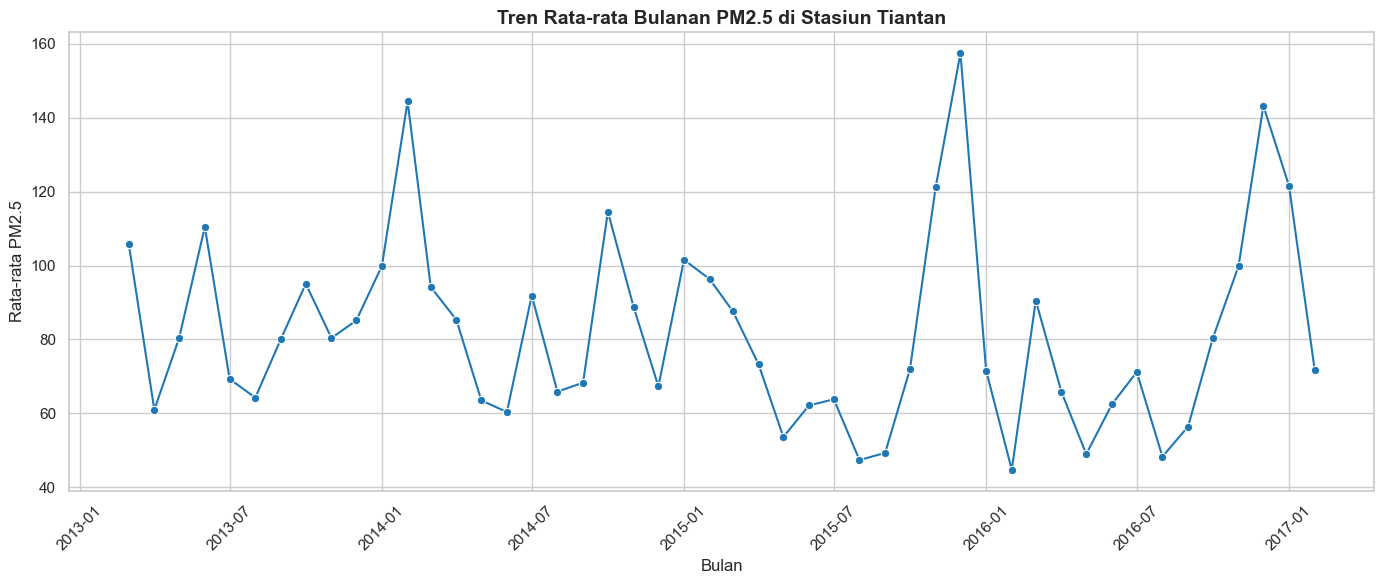

PM2.5 bulanan tertinggi: 2015-12 = 157.46
PM2.5 bulanan terendah: 2016-02 = 44.74


In [17]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_pollution, x="month_year_dt", y="PM2.5", marker="o", color="#1f77b4")
plt.title("Tren Rata-rata Bulanan PM2.5 di Stasiun Tiantan", fontsize=14, weight="bold")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pm25_max = monthly_pollution.loc[monthly_pollution["PM2.5"].idxmax(), ["month_year", "PM2.5"]]
pm25_min = monthly_pollution.loc[monthly_pollution["PM2.5"].idxmin(), ["month_year", "PM2.5"]]
print(f"PM2.5 bulanan tertinggi: {pm25_max['month_year']} = {pm25_max['PM2.5']:.2f}")
print(f"PM2.5 bulanan terendah: {pm25_min['month_year']} = {pm25_min['PM2.5']:.2f}")

**Insight:**

Tren PM2.5 bulanan tidak bergerak stabil, tetapi memperlihatkan lonjakan pada periode tertentu. Dalam data bersih ini, rata-rata PM2.5 bulanan tertinggi terjadi pada **Desember 2015** sekitar **157,46**, sedangkan nilai terendah terjadi pada **Februari 2016** sekitar **44,74**. Pola ini menunjukkan bahwa pemantauan bulanan penting untuk mendeteksi episode polusi tinggi, terutama pada akhir tahun.

### Pertanyaan 2: Perbandingan PM2.5 dan PM10 Berdasarkan Musim

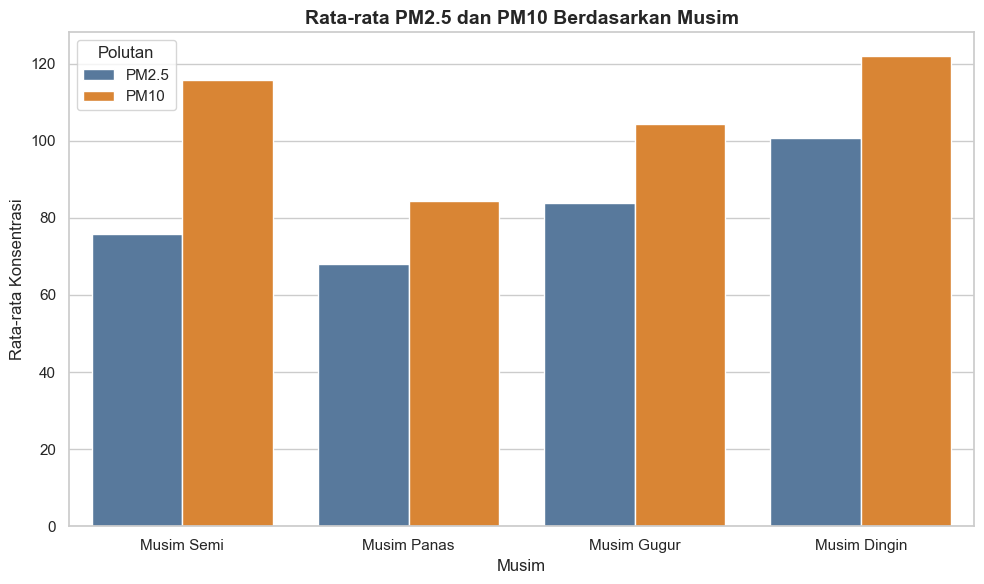

,PM2.5,PM10
season,,
Musim Semi,75.89,115.73
Musim Panas,68.05,84.38
Musim Gugur,83.94,104.27
Musim Dingin,100.63,122.04


In [ ]:
season_pm = season_pollution[["PM2.5", "PM10"]].reset_index().melt(
    id_vars="season", var_name="Polutan", value_name="Rata-rata"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=season_pm, x="season", y="Rata-rata", hue="Polutan", order=season_order, palette=["#4c78a8", "#f58518"])
plt.title("Rata-rata PM2.5 dan PM10 Berdasarkan Musim", fontsize=14, weight="bold")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Konsentrasi")
plt.legend(title="Polutan")
plt.tight_layout()
plt.show()

season_pollution[["PM2.5", "PM10"]]

**Insight:**

Musim dingin memiliki rata-rata PM2.5 tertinggi, yaitu sekitar **100,63**, dan PM10 juga tertinggi pada musim dingin sekitar **122,04**. PM10 pada musim semi juga relatif tinggi sekitar **115,73**, sehingga periode musim dingin dan musim semi perlu mendapat perhatian lebih dalam pengendalian partikulat.

### Pertanyaan 3: Korelasi Polutan dan Variabel Cuaca

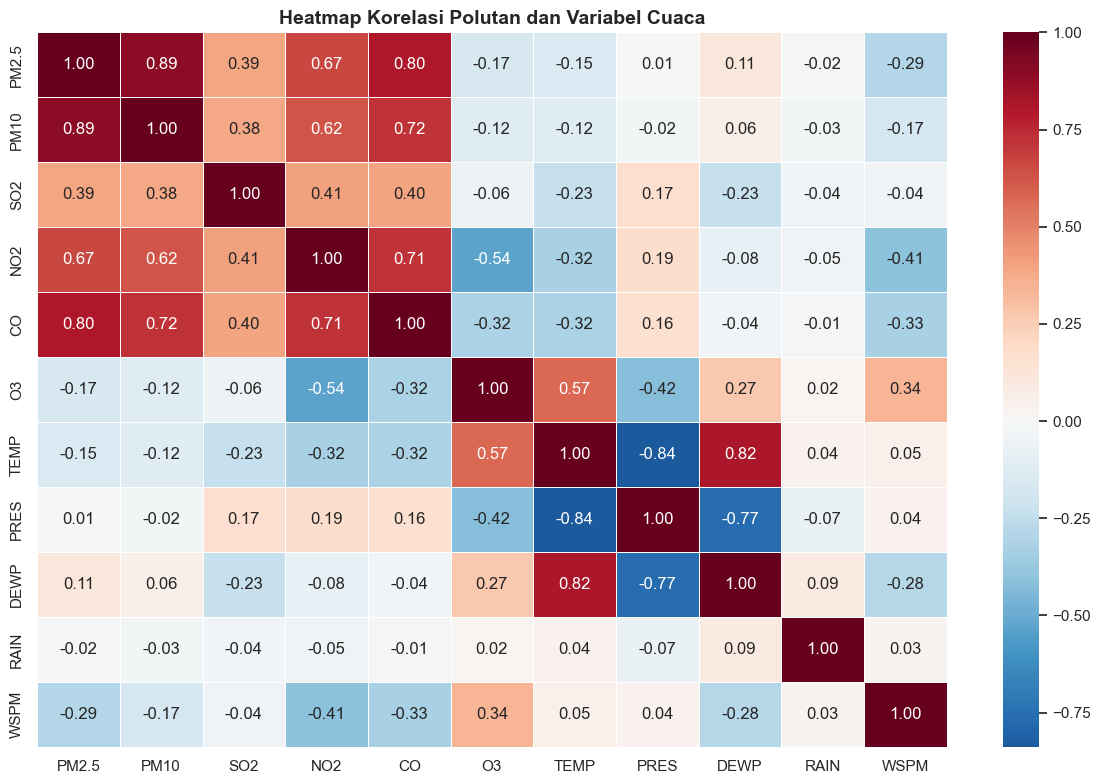

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Heatmap Korelasi Polutan dan Variabel Cuaca", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Insight:**

PM2.5 berkorelasi positif dengan beberapa polutan lain seperti PM10, NO2, dan CO, yang menunjukkan bahwa episode polusi sering terjadi bersamaan pada beberapa indikator. Di sisi cuaca, `WSPM` atau kecepatan angin memiliki korelasi negatif dengan PM2.5, sehingga angin yang lebih kuat cenderung membantu penyebaran polutan.

### Visualisasi Tambahan: Tren Polutan Utama dari Waktu ke Waktu

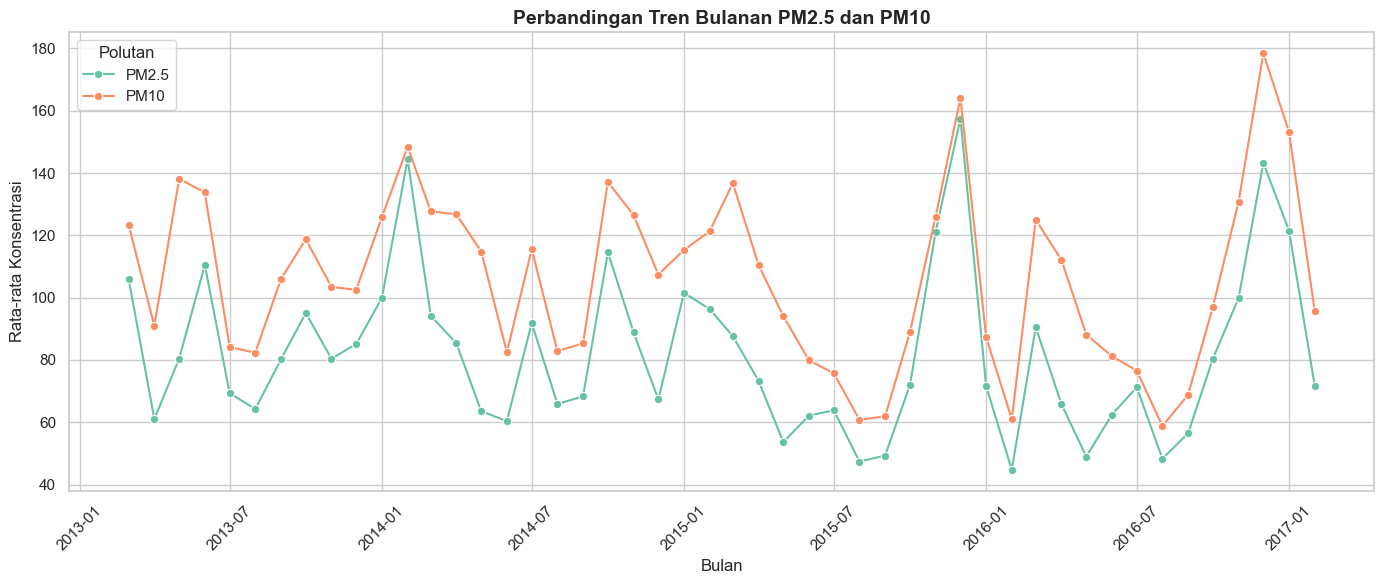

In [ ]:
monthly_long = monthly_pollution.melt(
    id_vars=["month_year", "month_year_dt"],
    value_vars=["PM2.5", "PM10"],
    var_name="Polutan",
    value_name="Rata-rata"
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_long, x="month_year_dt", y="Rata-rata", hue="Polutan", marker="o")
plt.title("Perbandingan Tren Bulanan PM2.5 dan PM10", fontsize=14, weight="bold")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Konsentrasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

PM10 umumnya berada di atas PM2.5 karena ukuran partikelnya mencakup fraksi yang lebih besar. Meski demikian, kedua polutan sering naik dan turun pada periode yang berdekatan, sehingga strategi pengendalian partikulat sebaiknya mempertimbangkan keduanya secara bersamaan.

## Conclusion

**Jawaban Pertanyaan 1:**

Tren rata-rata bulanan PM2.5 di Stasiun Tiantan selama Maret 2013 hingga Februari 2017 berfluktuasi dan menunjukkan beberapa lonjakan polusi. Bulan dengan rata-rata PM2.5 tertinggi adalah **Desember 2015** sekitar **157,46**, sedangkan yang terendah adalah **Februari 2016** sekitar **44,74**.

**Jawaban Pertanyaan 2:**

Musim dengan tingkat polusi partikulat tertinggi adalah **musim dingin**. Rata-rata PM2.5 pada musim dingin mencapai sekitar **100,63**, dan rata-rata PM10 mencapai sekitar **122,04**. PM10 juga relatif tinggi pada musim semi, sehingga dua musim tersebut perlu dipantau lebih ketat.

**Jawaban Pertanyaan 3:**

PM2.5 memiliki hubungan positif dengan beberapa polutan lain, terutama PM10, NO2, dan CO. Sementara itu, kecepatan angin (`WSPM`) memiliki hubungan negatif dengan PM2.5, yang mengindikasikan bahwa kondisi angin lebih kuat dapat membantu menurunkan konsentrasi polutan di udara.

**Rekomendasi Action Item:**

Pemerintah atau pengelola lingkungan dapat meningkatkan frekuensi pemantauan dan komunikasi risiko kualitas udara pada musim dingin, terutama saat rata-rata PM2.5 mulai meningkat. Selain itu, pengendalian sumber emisi partikulat perlu diprioritaskan pada periode musim dingin dan musim semi karena keduanya menunjukkan risiko PM2.5/PM10 yang lebih tinggi.